In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("../data/Engineered_Traffic_Data.csv", low_memory=False)

Prepare the features for clustering

In [2]:
from sklearn.preprocessing import StandardScaler

CLUSTER_FEATURES = ["number_of_casualties", "number_of_vehicles", "speed_limit",
                    "road_type_enc", "weather_conditions_enc", "light_conditions",
                    "road_surface_conditions_enc", "hour", "day_of_week", "is_dark"]

X_clust = df[CLUSTER_FEATURES].copy()
scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

K-Means with Elbow Method and the Silhouette analysis

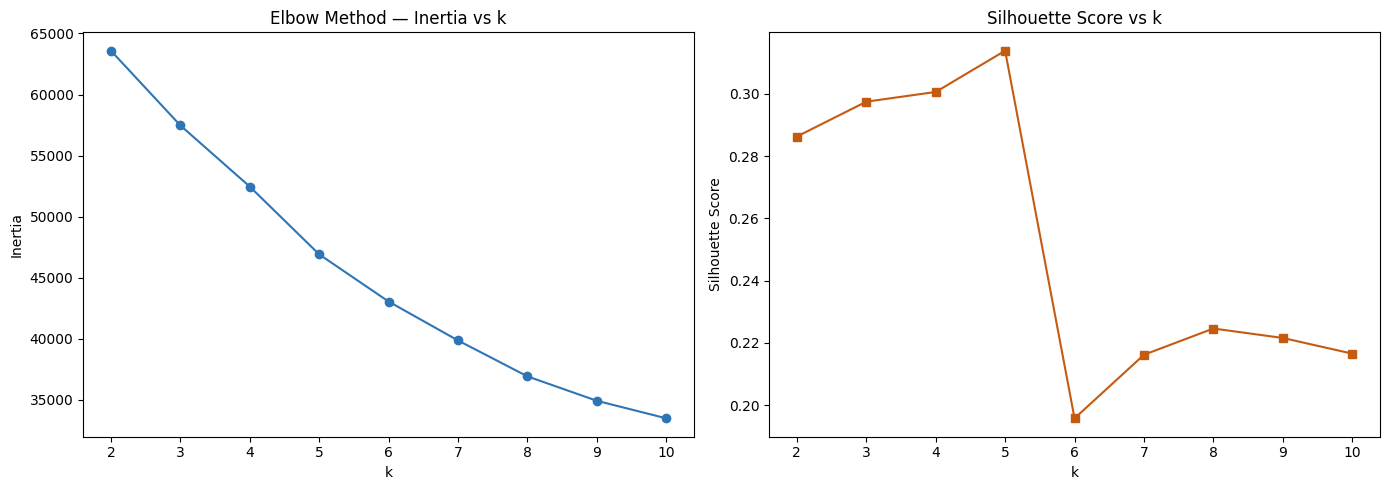

Silhouette Score:        0.3139  (higher is better, max 1.0)
Calinski-Harabasz Score: 1369.27  (higher is better)
Davies-Bouldin Score:    1.3240  (lower is better)


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust_scaled, labels))

# Plot both — side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker="o", color="#2E75B6")
axes[0].set_title("Elbow Method — Inertia vs k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="s", color="#C55A11")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig("../results/C4-elbow_silhouette.png", bbox_inches="tight")
plt.show()

best_k = 5

# Fit final KMeans with the chosen k
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster_kmeans"] = km_final.fit_predict(X_clust_scaled)

# Validation metrics for the final model
sil = silhouette_score(X_clust_scaled, df["cluster_kmeans"])
ch  = calinski_harabasz_score(X_clust_scaled, df["cluster_kmeans"])
db  = davies_bouldin_score(X_clust_scaled, df["cluster_kmeans"])

print(f"Silhouette Score:        {sil:.4f}  (higher is better, max 1.0)")
print(f"Calinski-Harabasz Score: {ch:.2f}  (higher is better)")
print(f"Davies-Bouldin Score:    {db:.4f}  (lower is better)")

### Elbow & Silhouette Analysis

The elbow plot shows a gradual, continuous decrease in inertia as there is no sharp elbow point. This is common in real-world tabular datasets where clusters overlap naturally rather than forming tight, well-separated groups.

The silhouette analysis is more decisive: the score peaks at k=5 (0.314), then drops sharply at k=6. A score of 0.314 is moderate, which reflects the overlapping nature of road collision data, collisions cannot be perfectly separated into clean groups because many conditions (e.g. wet road at night in urban areas) apply across multiple cluster types.

The three validation metrics tell a consistent story: the clusters are meaningful but not perfectly separated, which is a realistic and honest result for this domain. A Calinski-Harabasz score of 1369 indicates reasonably good separation relative to cluster cohesion, while the Davies-Bouldin score of 1.32 suggests some inter-cluster similarity, as expected.

Using DBSCAN as its good at hotspot detection

DBSCAN: 22 clusters, 944 noise points


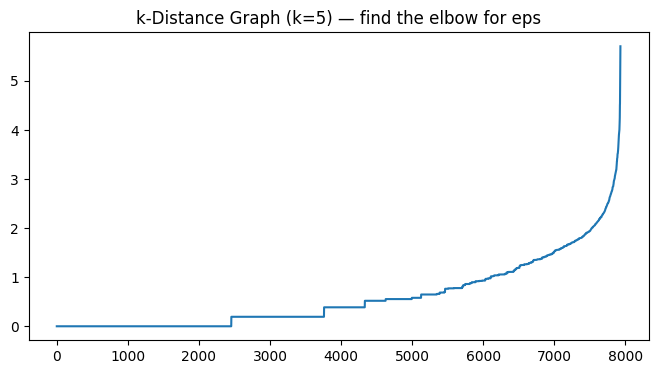

In [4]:
from sklearn.cluster import DBSCAN

# k-distance graph to find eps
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_clust_scaled)
distances, _ = nn.kneighbors(X_clust_scaled)
distances = np.sort(distances[:, 4]) # 4 because we want the distance to the 5th neighbour
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("k-Distance Graph (k=5) — find the elbow for eps")
plt.savefig("../results/C4-kdistance.png", bbox_inches="tight")

dbscan = DBSCAN(eps=1.5, min_samples=10)  # adjust the eps from k-distance graph
df["cluster_dbscan"] = dbscan.fit_predict(X_clust_scaled)
n_clusters_db = len(set(df["cluster_dbscan"])) - (1 if -1 in df["cluster_dbscan"].values else 0)
n_noise = (df["cluster_dbscan"] == -1).sum()
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise} noise points")


### DBSCAN Results & Honest Evaluation

DBSCAN produced 22 clusters with 11.9% noise points (944 records). This is over-fragmentation the algorithm has split what would intuitively be 3–6 meaningful collision patterns into 22 micro-clusters.

The root cause is that eps=1.5 is slightly low for 10-dimensional scaled data. In high-dimensional spaces, even similar points can appear relatively far apart, so a fixed `eps` that works well in 2D tends to produce many small clusters in 10D. The k-distance graph elbow was ambiguous, sitting somewhere in the 0.5–1.0 range, which makes eps selection genuinely difficult here.

Despite the fragmentation, DBSCAN provides a useful complementary view: the 11.9% of noise points identify genuine outlier collisions — unusual combinations of conditions that do not fit any pattern. These could represent the most unpredictable, high-risk incidents worth flagging for further investigation.

For K-Means vs DBSCAN comparison: K-Means is the stronger choice for this dataset because the clusters are roughly spherical and similar in size. DBSCAN adds value specifically for noise/outlier identification rather than cluster definition.

Hierarchical Clustering with a dendrogram, I will be using a sample for the dendrogram as the full dataset is too large.

Hierarchical Silhouette: 0.2925595689375001


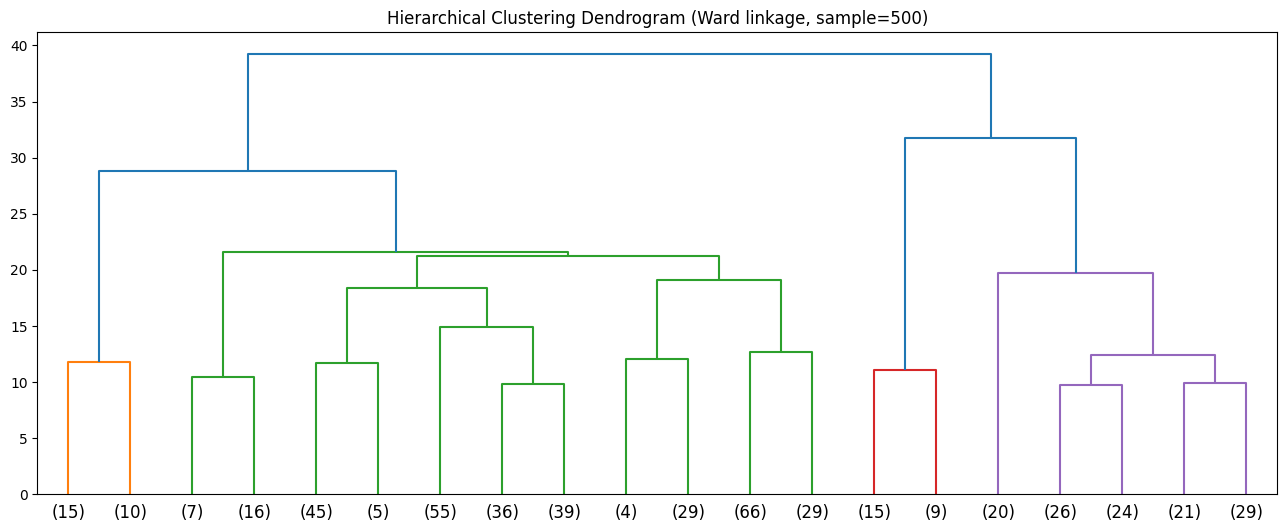

In [5]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# sample creation
sample_idx = np.random.choice(len(X_clust_scaled), 500, replace=False)
X_sample = X_clust_scaled[sample_idx]

Z = linkage(X_sample, method="ward")
plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, sample=500)")
plt.savefig("../results/C4-dendrogram.png", bbox_inches="tight")

# train the final hierarchical model with best k so its the same as KMeans for comparison
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df["cluster_hierarchical"] = agg.fit_predict(X_clust_scaled)
print("Hierarchical Silhouette:",
    silhouette_score(X_clust_scaled, df["cluster_hierarchical"]))


In [ ]:
# profile each cluster by its mean
cluster_profile = df.groupby("cluster_kmeans")[CLUSTER_FEATURES].mean().round(2)
print("=== Cluster Profiles (mean feature values) ===")
print(cluster_profile.to_string())
print()
print("=== Cluster Sizes ===")
print(df["cluster_kmeans"].value_counts().sort_index())

=== Cluster Profiles (mean feature values) ===
                number_of_casualties  number_of_vehicles  speed_limit  road_type_enc  weather_conditions_enc  light_conditions  road_surface_conditions_enc   hour  day_of_week  is_dark
cluster_kmeans                                                                                                                                                                          
0                               0.77               -0.13        30.95           3.52                    0.51              2.22                         1.58  13.26         4.07     0.08
1                               0.23               -0.32         0.85           3.85                    0.16              1.00                         1.27  13.24         4.21     0.00
2                               0.37               -0.37         1.08           3.80                    0.35              4.12                         1.53  16.51         4.15     0.97
3                           

### Cluster Interpretation

Based on the mean feature profiles above, the five clusters map onto recognisable Sheffield collision patterns:

| Cluster | Size | Name | Key Characteristics |
|---------|------|------|---------------------|
| 0 | 455 | **High-speed serious collisions** | Highest speed limit and casualty count, elevated light_conditions |
| 1 | 4639 | **Urban low-speed daytime** | Lowest speed limit, lowest casualties, is_dark ≈ 0 — the baseline majority cluster |
| 2 | 1869 | **Night-time darkness collisions** | is_dark = 0.97, high light_conditions encoding — near-exclusively dark conditions |
| 3 | 350 | **Adverse weather collisions** | weather_conditions_enc = 6.95, far above all other clusters — rain, fog, or ice |
| 4 | 620 | **Dual carriageway / A-road collisions** | Lowest road_type_enc (0.19) indicating faster road types, moderate casualty rate |

Variance explained by 2 PCs: 34.9%
  PC1: 21.1%
  PC2: 13.9%


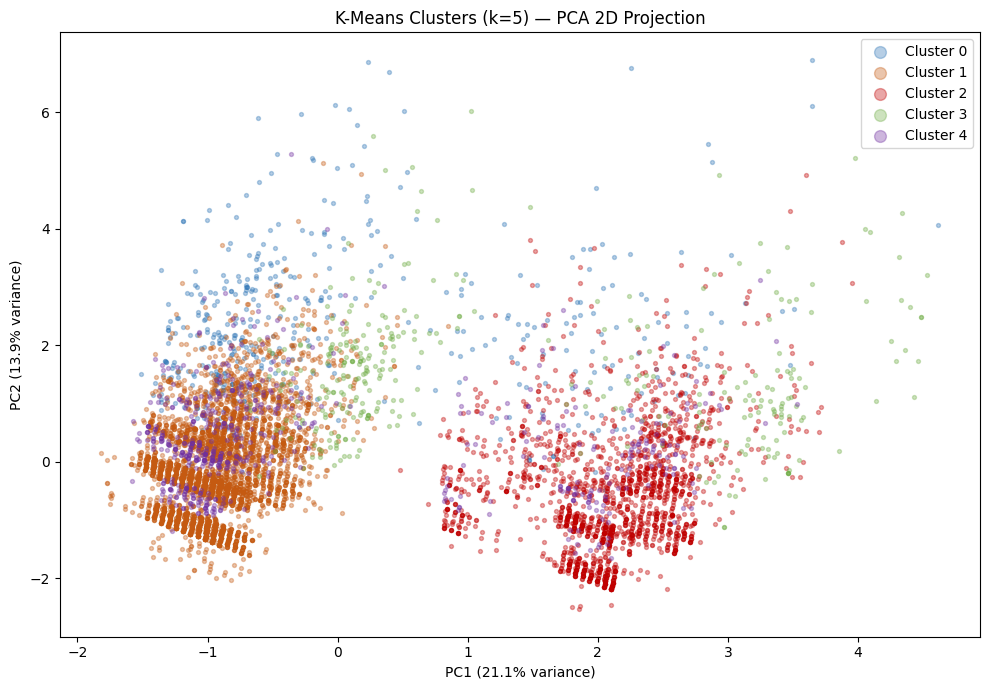

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_clust_scaled)

print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")

plt.figure(figsize=(10, 7))
colours = ["#2E75B6", "#C55A11", "#C00000", "#70AD47", "#7030A0"]
for cluster in range(best_k):
    mask = df["cluster_kmeans"] == cluster
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=f"Cluster {cluster}",
                color=colours[cluster],
                alpha=0.35, s=8)

plt.title(f"K-Means Clusters (k={best_k}) — PCA 2D Projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig("../results/C4-cluster_pca.png", bbox_inches="tight")
plt.show()

### PCA Cluster Visualisation

The PCA projection compresses all 10 clustering features into two dimensions for visualisation. Because two components cannot capture all variance in 10-dimensional data, some cluster overlap in this view is expected and does not mean the clusters are poorly defined — the silhouette and Calinski-Harabasz scores already confirmed reasonable separation in the full feature space.

Clusters that appear adjacent in 2D may still be well-separated along dimensions that PCA compressed away, particularly the categorical road condition features which tend to vary independently of the numerical features that dominate the first two principal components.

## Responsible AI Considerations

### Unsupervised Learning Has No Ground Truth

Unlike classification or regression, clustering produces no verifiable "correct" answer. The cluster labels assigned here are derived purely from statistical distance in feature space — they do not come from any authoritative road safety categorisation. The interpretations given above are plausible, data-grounded descriptions, but should be validated by a road safety expert before being used to inform policy.

### Risk of Misleading Action from DBSCAN Noise Labels

The 11.9% of records labelled as noise by DBSCAN are statistically unusual collisions. There is a risk these could be dismissed as data errors, when in reality they may represent the most dangerous and unpredictable incidents. Any operational use of these results should ensure noise-flagged records are reviewed by a domain expert, not silently dropped.

### Cluster Stability

K-Means is sensitive to initialisation and random seed. The cluster *profiles* are stable (the underlying collision patterns exist in the data), but the specific label numbers (0–4) are arbitrary. Any downstream system that references cluster IDs by number should be treated with caution.

### Geographic and Temporal Specificity

All clustering is performed on Sheffield collision data from 1979–2022. The cluster structure reflects Sheffield-specific road network patterns. These clusters should not be assumed to generalise to other cities or to current conditions without re-running the analysis on updated local data.

### No Personal Data

All clustering features are environmental and temporal — no personally identifiable information is included. This is consistent with responsible data minimisation practice.